# Plan 9 extensions: opportunity, cross-moments, and model remainder

This notebook reads immutable E9.7--E9.10 artifacts only. It neither trains nor repairs a learner. E9.11 was not run because its two predeclared gates failed.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'mnist_experiment' / 'rotated_mnist').is_dir()
)
artifact_root = repo_root / 'cache/mnist_experiment/rotated_mnist/plan9'
runs = {
    'E9.7': artifact_root / 'e9_7/rotated_mnist_plan9_e9_7_movement_opportunity__replica-0001__6109e38ad6876642',
    'E9.8': artifact_root / 'e9_8/rotated_mnist_plan9_e9_8_lagged_cross_moment__replica-0001__3a5f6c720b52b9f4',
    'E9.9': artifact_root / 'e9_9/rotated_mnist_plan9_e9_9_affinity_attribution_v2__replica-0001__c40471e46aa06d8f',
    'E9.10': artifact_root / 'e9_10/rotated_mnist_plan9_e9_10_opportunity_path_screen__replica-0001__2051e6774c0e6333',
}

def load_json(study, filename):
    run = runs[study]
    if not (run / 'COMPLETED').is_file():
        raise RuntimeError(f'{study} artifact is incomplete: {run}')
    path = run / filename
    if not path.is_file():
        raise RuntimeError(f'{study} is missing {filename}: {run}')
    return json.loads(path.read_text(encoding='utf-8'))

summaries = {study: load_json(study, 'summary.json') for study in runs}
e97_rows = pd.DataFrame(load_json('E9.7', 'audit_rows.json'))
e98_rows = pd.DataFrame(load_json('E9.8', 'audit_rows.json'))
e98_lags = pd.DataFrame(load_json('E9.8', 'lag_diagnostics.json'))
e99_rows = pd.DataFrame(load_json('E9.9', 'attribution_rows.json'))
e910_rows = pd.DataFrame(load_json('E9.10', 'screen_rows.json'))

pd.DataFrame([
    {'study': study, 'status': summary['status']}
    for study, summary in summaries.items()
]).assign(result=[
    'population opportunity absent',
    'cross-moment not promoted',
    'affinity remainder dominant in 3/4 groups',
    'no opportunity-qualified path',
])

,study,status,result
0,E9.7,supported,population opportunity absent
1,E9.8,inconclusive,cross-moment not promoted
2,E9.9,supported,affinity remainder dominant in 3/4 groups
3,E9.10,rejected,no opportunity-qualified path


## E9.7: Is there enough population opportunity?

The population movement premium is $S_t^{\mathrm{pop}}=\|d_t^\star\|_{G_t}^2$. Its action lift is $\Delta\pi_t=\pi_t^{\mathrm{marg}}-\pi_t^{\mathrm{cov}}$. The conditional analogue uses $\|d_t^\star-e_t\|_{G_t}^2$ and can be much larger, but it depends on the oracle anchor error $e_t$ and is not deployable.

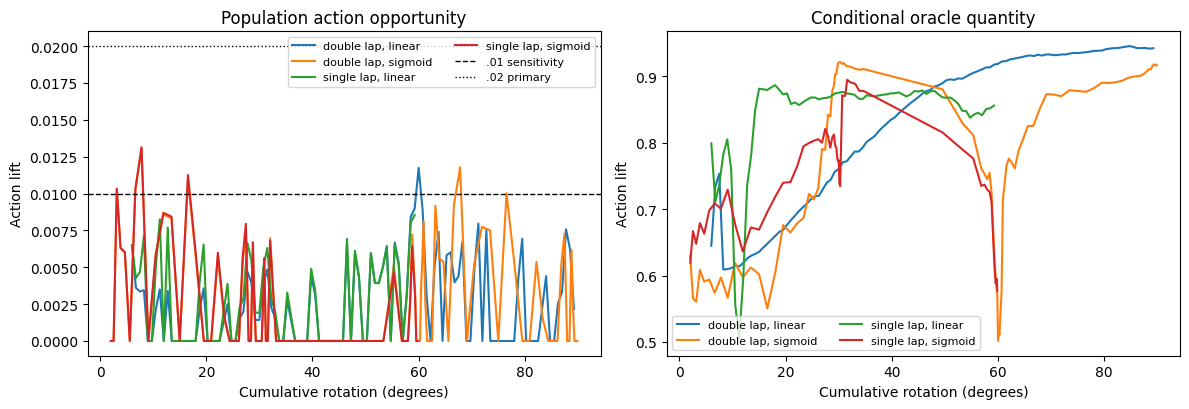

In [2]:
eligible = e97_rows[e97_rows.eligible & (e97_rows.condition == 'decomposed_edr')].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for (design, schedule), group in eligible.groupby(['design', 'schedule']):
    label = f"{design.replace('_', ' ')}, {schedule}"
    axes[0].plot(group.cumulative_angular_degrees, group.population_action_lift, label=label)
    axes[1].plot(group.cumulative_angular_degrees, group.conditional_action_lift, label=label)
axes[0].axhline(.01, color='black', linestyle='--', linewidth=1, label='.01 sensitivity')
axes[0].axhline(.02, color='black', linestyle=':', linewidth=1, label='.02 primary')
axes[0].set(title='Population action opportunity', xlabel='Cumulative rotation (degrees)', ylabel='Action lift')
axes[1].set(title='Conditional oracle quantity', xlabel='Cumulative rotation (degrees)', ylabel='Action lift')
axes[0].legend(fontsize=8, ncol=2)
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

No path sustained even a $.01$ population action lift for eight transitions. The striking conditional values diagnose realized anchor error; they do not identify the population or centered-marginal controller target.

## E9.8: Do lag-separated cross-moments recover movement?

The proposed estimator averages each eligible unordered pair once,

$$\widehat S_t^{\mathrm{cross}}=\frac{\sum_{i<j}a_{t,i}a_{t,j}\mathbf 1\{|i-j|>L\}Z_i^TG_tZ_j}{\sum_{i<j}a_{t,i}a_{t,j}\mathbf 1\{|i-j|>L\}},$$

with primary exclusion $L=1$. This aims to avoid subtracting a large self-noise estimate, but it requires longer-lag residual cross-products to be negligible.

,group,signed_signal_mae,e9_2_signed_signal_mae,clipping_fraction,mean_effective_pair_count
3,"double lap, linear",1.416,0.214,0.745,70.303
12,"double lap, sigmoid",1.962,0.863,0.511,48.587
21,"single lap, linear",4.668,1.001,0.818,233.291
30,"single lap, sigmoid",14.657,2.478,0.185,210.941


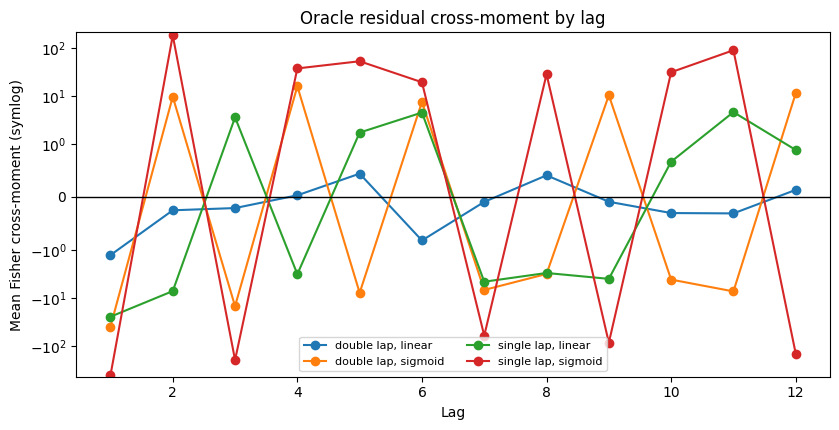

In [3]:
comparison = pd.DataFrame(summaries['E9.8']['group_summaries'])
primary_half_lives = {'double_lap': 3.75, 'single_lap': 15.0}
comparison = comparison[
    (comparison.lag_exclusion == 1)
    & np.isclose(comparison.half_life_degrees, comparison.design.map(primary_half_lives))
].copy()
comparison['group'] = comparison.design.str.replace('_', ' ') + ', ' + comparison.schedule
display(comparison[['group', 'signed_signal_mae', 'e9_2_signed_signal_mae', 'clipping_fraction', 'mean_effective_pair_count']].round(3))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
for (design, schedule), group in e98_lags.groupby(['design', 'schedule']):
    ax.plot(group.lag, group.mean_residual_cross_moment, marker='o', label=f"{design.replace('_', ' ')}, {schedule}")
ax.axhline(0, color='black', linewidth=1)
ax.set_yscale('symlog', linthresh=1)
ax.set(title='Oracle residual cross-moment by lag', xlabel='Lag', ylabel='Mean Fisher cross-moment (symlog)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

The signed cross-moment improved movement-energy MAE in zero of four groups. Large, alternating residual dependence survives beyond lag one. Better clipped actions are not movement recovery: negative estimates simply collapse onto the already strong covariance-only action.

## E9.9: What term was missing?

A disposable fresh-batch fit defines an operational affine remainder

$$a_{t+1}=\widehat\theta_{t+1}-(1-\pi_t)\widehat\theta_t-\pi_t\widetilde\theta_{t+1}.$$

The audit removes $a_{t+1}/\pi_t-a_t/\pi_{t-1}$ from the observed $Z_t$ and asks how much oracle residual Fisher energy remains. This attributes failure of the affine observation model; it does not make the disposable fit part of a controller.

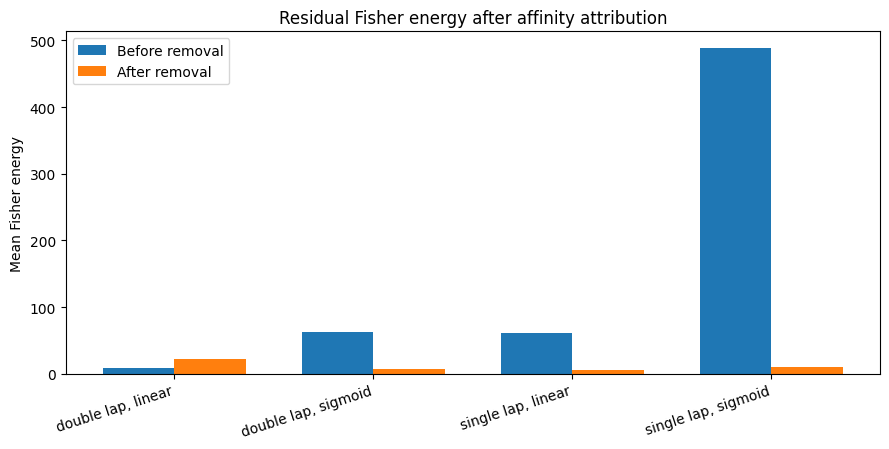

,group,mean_residual_affinity_cosine,median_energy_reduction_fraction
0,"double lap, linear",0.030,-18.489
1,"double lap, sigmoid",0.866,0.854
2,"single lap, linear",0.884,0.877
3,"single lap, sigmoid",0.907,0.931


In [4]:
affinity = pd.DataFrame(summaries['E9.9']['group_summaries'])
affinity['group'] = affinity.design.str.replace('_', ' ') + ', ' + affinity.schedule
x = np.arange(len(affinity))
width = .36
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(x - width / 2, affinity.mean_residual_energy, width, label='Before removal')
ax.bar(x + width / 2, affinity.mean_post_affinity_energy, width, label='After removal')
ax.set_xticks(x, affinity.group, rotation=18, ha='right')
ax.set(title='Residual Fisher energy after affinity attribution', ylabel='Mean Fisher energy')
ax.legend()
fig.tight_layout()
plt.show()
display(affinity[['group', 'mean_residual_affinity_cosine', 'median_energy_reduction_fraction']].round(3))

Affinity removal cut mean residual energy by more than half in three groups, with residual/remainder cosine from $.866$ to $.907$. Double-lap linear is a real counterexample. Direct 50-versus-100-step fits were identical at all 48 sensitivity points, so the result is not explained by the tested optimizer budget.

## E9.10: Can faster rotation create a valid challenge?

The screen retains $m=4$ and varies transitions per arrow. A candidate must sustain at least $.02$ action lift for eight transitions while keeping local drift variation at or below $.25$. Predictive outcomes are sealed from selection.

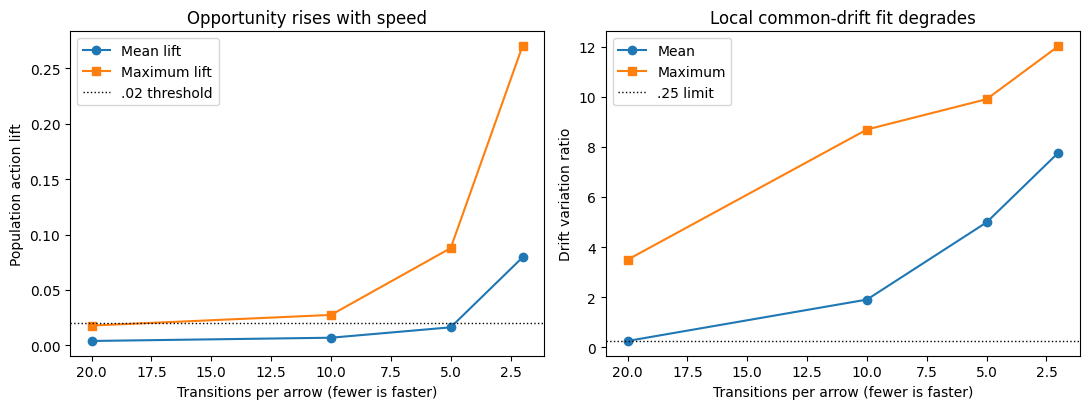

,transitions_per_arrow,mean_action_lift,longest_threshold_run,mean_drift_variation_ratio,qualified
3,2,0.079,2,7.768,False
2,5,0.016,3,4.984,False
1,10,0.007,1,1.901,False
0,20,0.004,0,0.249,False


In [5]:
screen = pd.DataFrame(summaries['E9.10']['candidate_summaries']).sort_values('transitions_per_arrow')
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(screen.transitions_per_arrow, screen.mean_action_lift, marker='o', label='Mean lift')
axes[0].plot(screen.transitions_per_arrow, screen.maximum_action_lift, marker='s', label='Maximum lift')
axes[0].axhline(.02, color='black', linestyle=':', linewidth=1, label='.02 threshold')
axes[0].set(title='Opportunity rises with speed', xlabel='Transitions per arrow (fewer is faster)', ylabel='Population action lift')
axes[0].invert_xaxis()
axes[0].legend()
axes[1].plot(screen.transitions_per_arrow, screen.mean_drift_variation_ratio, marker='o', label='Mean')
axes[1].plot(screen.transitions_per_arrow, screen.maximum_drift_variation_ratio, marker='s', label='Maximum')
axes[1].axhline(.25, color='black', linestyle=':', linewidth=1, label='.25 limit')
axes[1].set(title='Local common-drift fit degrades', xlabel='Transitions per arrow (fewer is faster)', ylabel='Drift variation ratio')
axes[1].invert_xaxis()
axes[1].legend()
fig.tight_layout()
plt.show()
display(screen[['transitions_per_arrow', 'mean_action_lift', 'longest_threshold_run', 'mean_drift_variation_ratio', 'qualified']].round(3))

## Gate decision

Faster paths create a larger movement premium, but not a sustained one inside the local common-drift regime. E9.8 therefore supplies no supported observer and E9.10 supplies no qualified path. E9.11 remains **Blocked** without an artifact.

The useful result is diagnostic: the current $Z_t$ observation model is misspecified by an EWC-affinity remainder on most tested paths, while rotated MNIST cannot increase population movement opportunity cleanly enough to justify another prospective learner. This is a disciplined stopping point, not evidence against adaptive control on every manifold.